# LM Judge Accuracy Evaluation — CLAMBER Dataset

Evaluates whether the LM judge correctly classifies clarifying questions as **EPISTEMIC** or **ALEATORIC**
using 100 entries from the CLAMBER benchmark as ground truth.

## Ground-truth mapping from CLAMBER taxonomy

CLAMBER defines three top-level categories, each with subclasses:

| CLAMBER category | Subclass | Mapped label | Rationale |
|---|---|---|---|
| **FD** — Epistemic Misalignment | `NK` (Unfamiliar entity) | **EPISTEMIC** | Model doesn't recognise the entity — a knowledge gap |
| **FD** — Epistemic Misalignment | `ICL` (Contradiction) | **EPISTEMIC** | Conflicting examples expose a knowledge/reasoning gap |
| **LA** — Linguistic Ambiguity | `polysemy` (Lexical) | **ALEATORIC** | Word has multiple valid meanings — irreducible |
| **LA** — Linguistic Ambiguity | `co-reference` (Semantic) | **ALEATORIC** | Pronoun/reference is ambiguous — context-dependent |
| **MC** — Aleatoric Output | `whom` | **ALEATORIC** | Missing personal/preference details |
| **MC** — Aleatoric Output | `what` | **ALEATORIC** | Missing task-specific details |
| **MC** — Aleatoric Output | `when` | **ALEATORIC** | Missing temporal details |
| **MC** — Aleatoric Output | `where` | **ALEATORIC** | Missing spatial details |

**Input to judge:** `clarifying_question` field (ground-truth CQ from CLAMBER)  
**Target:** 50 epistemic (25 NK + 25 ICL) + 50 aleatoric (mixed MC + LA subclasses)

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("../../").resolve()))

# ── Dataset config — change DATASET to switch experiments ─────────────────
DATASET           = "clamber"
ROOT              = Path("../../").resolve()
DATASETS_DIR      = ROOT / "datasets" / DATASET
OUTPUTS_DIR       = ROOT / "outputs"  / DATASET
PROMPTS_DIR       = ROOT / "prompts"  / "medqa"   # judge instruction is shared

CLAMBER_PATH         = DATASETS_DIR / "clamber_benchmark.jsonl"
JUDGE_INSTRUCTION    = PROMPTS_DIR  / "judge_instruction.txt"
OUTPUT_CSV_BASELINE  = OUTPUTS_DIR  / "clamber_judge_eval_baseline.csv"
OUTPUT_CSV_FEWSHOT   = OUTPUTS_DIR  / "clamber_judge_eval_fewshot.csv"

# ── Sampling config ───────────────────────────────────────────────────────
N_PER_CLASS       = 100     # 100 epistemic + 100 aleatoric = 200 total
RANDOM_SEED       = 42

# ── Model / run config ────────────────────────────────────────────────────
MODEL_ID          = "gemini-2.5-flash"
REQUEST_INTERVAL  = 1.0

# ── Few-shot exclusion set — these strings MUST NOT appear in the eval pool
# Keep in sync with FEW_SHOT_EXAMPLES defined later in this notebook.
FEW_SHOT_QUESTIONS = {
    "What is the context or field in which 'Comallcium' is typically used or referenced?",
    "Is the category either animal or outdoor location?",
    "Is the category either religious leader or male pronoun?",
    "What does she refer to? the sister-in-law or Amanda?",
    "Which year: 1984, 1985, 1998, 2004, or 2009?",
    "What factors are most important to you in a job, such as salary, location, career growth, or company culture?",
}
# ─────────────────────────────────────────────────────────────────────────

OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"Excluded from eval pool: {len(FEW_SHOT_QUESTIONS)} few-shot questions")

Excluded from eval pool: 6 few-shot questions


In [2]:
import json
import logging
import random
import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

from src.utils import load_dotenv
from src.providers import GeminiProvider
from src.judge import LLMJudge, CSVBatchClassifier, FewShotExample

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(name)s — %(message)s",
    datefmt="%H:%M:%S",
)

load_dotenv(ROOT / ".env")
print("Environment loaded.")

Environment loaded.


## Load & Sample CLAMBER

In [3]:
# CLAMBER is double-encoded JSON: each line is a JSON string containing JSON
raw_rows = []
with open(CLAMBER_PATH, encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            outer = json.loads(line)
            raw_rows.append(json.loads(outer))

df = pd.DataFrame(raw_rows)
print(f"Total CLAMBER rows: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print()
print("Subclass counts:")
print(df["subclass"].value_counts())
print()
print("Category counts:")
print(df["category"].value_counts())

Total CLAMBER rows: 3202
Columns: ['question', 'context', 'clarifying_question', 'require_clarification', 'category', 'subclass', 'predict_ambiguous', 'predict_is_ambiguous_response', 'predict_clarifying_question']

Subclass counts:
subclass
none            801
NK              400
ICL             400
co-reference    400
polysemy        400
what            201
whom            200
when            200
where           200
Name: count, dtype: int64

Category counts:
category
MC    1602
FD     800
LA     800
Name: count, dtype: int64


In [4]:
# ── Ground-truth mapping ──────────────────────────────────────────────────
EPISTEMIC_SUBCLASSES = {"NK", "ICL"}
ALEATORIC_SUBCLASSES = {"polysemy", "co-reference", "whom", "what", "when", "where"}

# Exclude few-shot questions BEFORE sampling to prevent data leakage
not_few_shot = ~df["clarifying_question"].isin(FEW_SHOT_QUESTIONS)
has_cq = (
    df["clarifying_question"].notna()
    & (df["clarifying_question"].str.strip() != "")
    & not_few_shot
)

epistemic_pool = df[df["subclass"].isin(EPISTEMIC_SUBCLASSES) & has_cq].copy()
aleatoric_pool = df[df["subclass"].isin(ALEATORIC_SUBCLASSES) & has_cq].copy()

print(f"Few-shot questions excluded from pools: {int((~not_few_shot).sum())}")
print(f"Epistemic pool (NK + ICL): {len(epistemic_pool)}")
print(epistemic_pool["subclass"].value_counts().to_string())
print()
print(f"Aleatoric pool (MC + LA): {len(aleatoric_pool)}")
print(aleatoric_pool["subclass"].value_counts().to_string())

# ── Balanced sampling: 50 NK + 50 ICL for epistemic ──────────────────────
n_each_epi = N_PER_CLASS // 2   # 50 per epistemic subclass

epi_nk  = epistemic_pool[epistemic_pool["subclass"] == "NK"].sample(n=n_each_epi, random_state=RANDOM_SEED)
epi_icl = epistemic_pool[epistemic_pool["subclass"] == "ICL"].sample(n=n_each_epi, random_state=RANDOM_SEED)
epi_sample = pd.concat([epi_nk, epi_icl], ignore_index=True)

# 100 aleatoric drawn proportionally across subclasses
ale_sample = aleatoric_pool.sample(n=N_PER_CLASS, random_state=RANDOM_SEED)

epi_sample = epi_sample.copy()
ale_sample = ale_sample.copy()
epi_sample["true_label"] = "EPISTEMIC"
ale_sample["true_label"] = "ALEATORIC"

eval_df = pd.concat([epi_sample, ale_sample], ignore_index=True).sample(
    frac=1, random_state=RANDOM_SEED
).reset_index(drop=True)

eval_df["eval_id"] = [f"clamber_{i:03d}" for i in range(len(eval_df))]

# ── Sanity check: confirm zero overlap with few-shot questions ────────────
overlap = eval_df[eval_df["clarifying_question"].isin(FEW_SHOT_QUESTIONS)]
assert len(overlap) == 0, f"DATA LEAKAGE: {len(overlap)} few-shot questions found in eval set!"
print(f"\n✓ Leak check passed — 0 few-shot questions in eval set")
print(f"Evaluation set: {len(eval_df)} rows")
print("\nSubclass distribution:")
print(eval_df.groupby(["true_label", "subclass"]).size().to_string())
print()
print(eval_df[["eval_id", "subclass", "true_label", "clarifying_question"]].head(10).to_string(index=False))

Few-shot questions excluded from pools: 109
Epistemic pool (NK + ICL): 365
subclass
NK     200
ICL    165

Aleatoric pool (MC + LA): 1127
subclass
what            201
where           200
polysemy        200
whom            199
when            199
co-reference    128

✓ Leak check passed — 0 few-shot questions in eval set
Evaluation set: 200 rows

Subclass distribution:
true_label  subclass    
ALEATORIC   co-reference    10
            polysemy        15
            what            19
            when            15
            where           23
            whom            18
EPISTEMIC   ICL             50
            NK              50

    eval_id     subclass true_label                                                                                                                                                                  clarifying_question
clamber_000          ICL  EPISTEMIC                                                                                                      

## Run LM Judge

## Few-Shot Examples

Six examples chosen to target the three failure modes from the baseline run:

| Failure mode | Baseline accuracy | Pattern | Fix |
|---|---|---|---|
| `ICL` (EPISTEMIC) | 32% | "Is the category either X or Y?" read as aleatoric | Show that binary-option CQs can be epistemic when the model is resolving a contradiction |
| `co-reference` (ALEATORIC) | 0% | "What does she refer to? X or Y?" read as epistemic | Show that pronoun disambiguation is aleatoric — the referent is context-dependent, not a knowable fact |
| `when/what` (ALEATORIC) | ~65% | "Which year/episode: X, Y, Z?" read as epistemic | Show that multi-option CQs asking the user to choose between items are aleatoric |

In [5]:
FEW_SHOT_EXAMPLES = [
    # ── EPISTEMIC: NK — model encounters a completely unknown entity ────────
    FewShotExample(
        input="What is the context or field in which 'Comallcium' is typically used or referenced?",
        expected_output="EPISTEMIC",
        explanation=(
            "The model has never encountered this entity and is asking for information "
            "to fill a specific knowledge gap. A definitive answer exists — once the user "
            "provides context the uncertainty is completely resolved."
        ),
    ),
    # ── EPISTEMIC: ICL — model hits contradictory examples in the query ────
    FewShotExample(
        input="Is the category either animal or outdoor location?",
        expected_output="EPISTEMIC",
        explanation=(
            "The query contains examples that contradict each other under any single "
            "category rule the model knows. The binary phrasing does NOT mean multiple "
            "valid answers exist — it means the model cannot reconcile the contradiction "
            "with its knowledge. There is one correct categorisation; the model simply "
            "cannot determine it. This is a knowledge/reasoning gap, not a preference gap."
        ),
    ),
    # ── EPISTEMIC: ICL variant — same pattern, different domain ───────────
    FewShotExample(
        input="Is the category either religious leader or male pronoun?",
        expected_output="EPISTEMIC",
        explanation=(
            "Same ICL pattern: the model is exposing an internal contradiction it cannot "
            "resolve. The two options are not equally valid user preferences — one is the "
            "correct answer according to the underlying rule, and the model lacks the "
            "knowledge to determine which."
        ),
    ),
    # ── ALEATORIC: co-reference — pronoun with no resolvable referent ──────
    FewShotExample(
        input="What does she refer to? the sister-in-law or Amanda?",
        expected_output="ALEATORIC",
        explanation=(
            "The pronoun 'she' could validly refer to either person. This is NOT a "
            "knowledge gap — no additional fact or training data can determine the "
            "correct referent. Only the user's original conversational context can "
            "resolve it, making this irreducibly ambiguous."
        ),
    ),
    # ── ALEATORIC: MC/when — user must choose between valid time options ───
    FewShotExample(
        input="Which year: 1984, 1985, 1998, 2004, or 2009?",
        expected_output="ALEATORIC",
        explanation=(
            "The query is underspecified across multiple valid years. The model is "
            "asking the user to select which version or instance they mean — all "
            "options are equally valid. No external fact can determine which year "
            "the user intends; only the user can resolve this."
        ),
    ),
    # ── ALEATORIC: MC/whom — answer depends on personal preference ─────────
    FewShotExample(
        input="What factors are most important to you in a job, such as salary, location, career growth, or company culture?",
        expected_output="ALEATORIC",
        explanation=(
            "The correct answer depends entirely on the individual user's preferences. "
            "No fact, no training data, and no amount of knowledge can resolve this — "
            "it is inherently personal and has many equally valid answers."
        ),
    ),
]

print(f"Defined {len(FEW_SHOT_EXAMPLES)} few-shot examples.")

Defined 6 few-shot examples.


In [6]:
# Save the eval set as the input CSV for the batch classifier
INPUT_CSV = OUTPUTS_DIR / "clamber_eval_input.csv"
eval_df[["eval_id", "subclass", "true_label", "clarifying_question"]].to_csv(
    INPUT_CSV, index=False
)
print(f"Eval input saved: {INPUT_CSV}  ({len(eval_df)} rows)")

Eval input saved: D:\final_project\pilot_study\outputs\clamber\clamber_eval_input.csv  (200 rows)


In [7]:
# ── Baseline run (0-shot, no few-shot examples) ───────────────────────────
REGENERATE_BASELINE = False  # set True to force a fresh run

if OUTPUT_CSV_BASELINE.exists() and not REGENERATE_BASELINE:
    print(f"Loading existing baseline results from {OUTPUT_CSV_BASELINE}")
else:
    if REGENERATE_BASELINE and OUTPUT_CSV_BASELINE.exists():
        OUTPUT_CSV_BASELINE.unlink()
        print("Deleted existing baseline output — regenerating.")

    provider_b = GeminiProvider(model_id=MODEL_ID)

    judge_baseline = LLMJudge(
        provider=provider_b,
        instructions_path=JUDGE_INSTRUCTION,
        few_shot_examples=[],          # zero-shot
        label_parser=lambda text: text.strip().upper(),
    )

    classifier_baseline = CSVBatchClassifier(
        judge=judge_baseline,
        input_csv=INPUT_CSV,
        output_csv=OUTPUT_CSV_BASELINE,
        question_column="clarifying_question",
        id_column="eval_id",
        delay_between_calls=REQUEST_INTERVAL,
    )

    classifier_baseline.run()
    print(f"Baseline classification complete. Results at {OUTPUT_CSV_BASELINE}")

07:04:27 [INFO] src.providers — GeminiProvider ready — model=gemini-2.5-flash api_version=v1beta


07:04:27 [INFO] src.judge — LLMJudge ready — provider=gemini model=gemini-2.5-flash few_shot_count=0


07:04:27 [INFO] src.judge — Evaluating: 'Is the category either does not contain a negation or proper...'


07:04:27 [INFO] google_genai.models — AFC is enabled with max remote calls: 10.


07:04:29 [INFO] httpx — HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent "HTTP/1.1 200 OK"


...

07:13:52 [INFO] google_genai.models — AFC is enabled with max remote calls: 10.


07:13:53 [INFO] httpx — HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent "HTTP/1.1 200 OK"


07:13:53 [INFO] src.judge — label='ALEATORIC' latency=1.727s


07:13:54 [INFO] src.judge — Batch complete — total=200 classified=200 skipped=0 errors=0


Baseline classification complete. Results at D:\final_project\pilot_study\outputs\clamber\clamber_judge_eval_baseline.csv


In [8]:
# ── Few-shot run (6 examples) ─────────────────────────────────────────────
REGENERATE_FEWSHOT = False  # set True to force a fresh run

if OUTPUT_CSV_FEWSHOT.exists() and not REGENERATE_FEWSHOT:
    print(f"Loading existing few-shot results from {OUTPUT_CSV_FEWSHOT}")
else:
    if REGENERATE_FEWSHOT and OUTPUT_CSV_FEWSHOT.exists():
        OUTPUT_CSV_FEWSHOT.unlink()
        print("Deleted existing few-shot output — regenerating.")

    provider_f = GeminiProvider(model_id=MODEL_ID)

    judge_fewshot = LLMJudge(
        provider=provider_f,
        instructions_path=JUDGE_INSTRUCTION,
        few_shot_examples=FEW_SHOT_EXAMPLES,
        label_parser=lambda text: text.strip().upper(),
    )

    classifier_fewshot = CSVBatchClassifier(
        judge=judge_fewshot,
        input_csv=INPUT_CSV,
        output_csv=OUTPUT_CSV_FEWSHOT,
        question_column="clarifying_question",
        id_column="eval_id",
        delay_between_calls=REQUEST_INTERVAL,
    )

    classifier_fewshot.run()
    print(f"Few-shot classification complete. Results at {OUTPUT_CSV_FEWSHOT}")

07:13:54 [INFO] src.providers — GeminiProvider ready — model=gemini-2.5-flash api_version=v1beta


07:13:54 [INFO] src.judge — LLMJudge ready — provider=gemini model=gemini-2.5-flash few_shot_count=6


07:13:54 [INFO] src.judge — Evaluating: 'Is the category either does not contain a negation or proper...'


07:13:54 [INFO] google_genai.models — AFC is enabled with max remote calls: 10.


07:13:56 [INFO] httpx — HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent "HTTP/1.1 200 OK"


...

07:23:16 [INFO] google_genai.models — AFC is enabled with max remote calls: 10.


07:23:18 [INFO] httpx — HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent "HTTP/1.1 200 OK"


07:23:18 [INFO] src.judge — label='ALEATORIC' latency=2.370s


07:23:19 [INFO] src.judge — Batch complete — total=200 classified=200 skipped=0 errors=0


Few-shot classification complete. Results at D:\final_project\pilot_study\outputs\clamber\clamber_judge_eval_fewshot.csv


## Accuracy Analysis

In [9]:
def compute_accuracy(results_path, label=""):
    results_df = pd.read_csv(results_path)
    merged = eval_df[["eval_id", "subclass", "true_label", "clarifying_question"]].merge(
        results_df[["id", "label", "latency_seconds", "error"]].rename(columns={"id": "eval_id"}),
        on="eval_id", how="left",
    )
    merged["predicted_label"] = merged["label"].str.strip().str.upper()
    merged["valid_prediction"] = merged["predicted_label"].isin({"EPISTEMIC", "ALEATORIC"})
    merged["correct"] = merged["true_label"] == merged["predicted_label"]
    return merged

baseline = compute_accuracy(OUTPUT_CSV_BASELINE, label="Baseline")
fewshot  = compute_accuracy(OUTPUT_CSV_FEWSHOT,  label="Few-shot")

def summary(df):
    v = df[df["valid_prediction"]]
    return {
        "total": len(df),
        "valid": len(v),
        "correct": int(v["correct"].sum()),
        "accuracy": v["correct"].mean(),
    }

b, f = summary(baseline), summary(fewshot)
display(Markdown(f"""
### Overall Results

| Metric | Baseline (0-shot) | Few-shot (6 examples) | Δ |
|---|---|---|---|
| Total | {b['total']} | {f['total']} | — |
| Valid predictions | {b['valid']} | {f['valid']} | — |
| Correct | {b['correct']} | {f['correct']} | {f['correct']-b['correct']:+d} |
| **Accuracy** | **{b['accuracy']:.1%}** | **{f['accuracy']:.1%}** | **{f['accuracy']-b['accuracy']:+.1%}** |
"""))

# Per-class
print("Per-class accuracy:")
for df_, name in [(baseline, "Baseline"), (fewshot, "Few-shot")]:
    v = df_[df_["valid_prediction"]]
    pc = v.groupby("true_label")["correct"].mean().map("{:.1%}".format)
    print(f"  {name}: {pc.to_dict()}")

# Per-subclass comparison
print("\nPer-subclass accuracy (Baseline → Few-shot):")
sub_b = baseline[baseline["valid_prediction"]].groupby(["true_label","subclass"])["correct"].mean()
sub_f = fewshot[fewshot["valid_prediction"]].groupby(["true_label","subclass"])["correct"].mean()
comp = pd.DataFrame({"baseline": sub_b, "fewshot": sub_f})
comp["delta"] = comp["fewshot"] - comp["baseline"]
comp["baseline"] = comp["baseline"].map("{:.1%}".format)
comp["fewshot"]  = comp["fewshot"].map("{:.1%}".format)
comp["delta"]    = comp["delta"].map("{:+.1%}".format)
display(comp)


### Overall Results

| Metric | Baseline (0-shot) | Few-shot (6 examples) | Δ |
|---|---|---|---|
| Total | 200 | 200 | — |
| Valid predictions | 200 | 200 | — |
| Correct | 136 | 189 | +53 |
| **Accuracy** | **68.0%** | **94.5%** | **+26.5%** |


Per-class accuracy:
  Baseline: {'ALEATORIC': '64.0%', 'EPISTEMIC': '72.0%'}
  Few-shot: {'ALEATORIC': '89.0%', 'EPISTEMIC': '100.0%'}

Per-subclass accuracy (Baseline → Few-shot):


baseline fewshot   delta
true_label subclass                             
ALEATORIC  co-reference    30.0%  100.0%  +70.0%
           polysemy        86.7%  100.0%  +13.3%
           what            73.7%   78.9%   +5.3%
           when            26.7%   86.7%  +60.0%
           where           60.9%   91.3%  +30.4%
           whom            88.9%   83.3%   -5.6%
EPISTEMIC  ICL             48.0%  100.0%  +52.0%
           NK              96.0%  100.0%   +4.0%

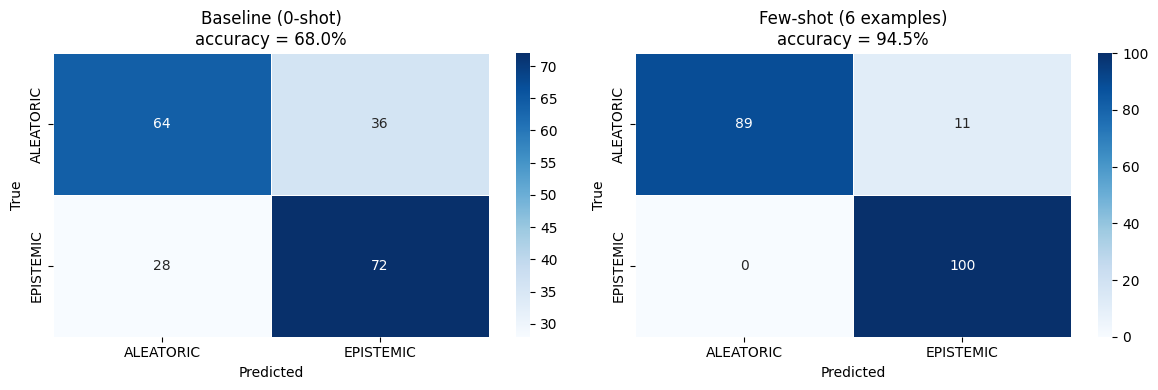

Saved to D:\final_project\pilot_study\outputs\clamber\confusion_comparison.png


In [10]:
# ── Side-by-side confusion matrices ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, df, title, fname in [
    (axes[0], baseline,  f"Baseline (0-shot)\naccuracy = {summary(baseline)['accuracy']:.1%}",  "confusion_baseline.png"),
    (axes[1], fewshot,   f"Few-shot (6 examples)\naccuracy = {summary(fewshot)['accuracy']:.1%}", "confusion_fewshot.png"),
]:
    valid = df[df["valid_prediction"]]
    cm = pd.crosstab(valid["true_label"], valid["predicted_label"],
                     rownames=["True"], colnames=["Predicted"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, linewidths=0.5)
    ax.set_title(title)

fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "confusion_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {OUTPUTS_DIR / 'confusion_comparison.png'}")

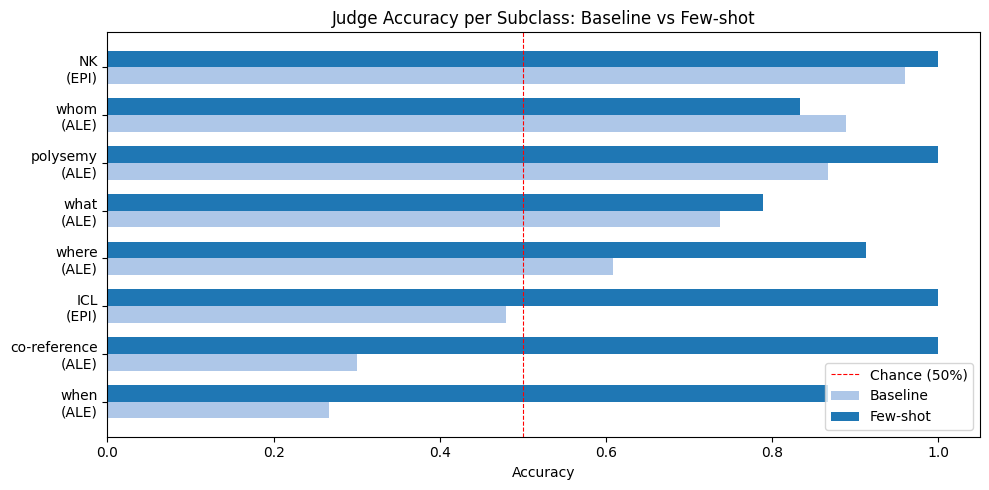

In [11]:
# ── Per-subclass accuracy: Baseline vs Few-shot ───────────────────────────
sub_b = (baseline[baseline["valid_prediction"]]
         .groupby(["subclass","true_label"])["correct"].mean().reset_index()
         .rename(columns={"correct":"accuracy"}))
sub_b["run"] = "Baseline"

sub_f = (fewshot[fewshot["valid_prediction"]]
         .groupby(["subclass","true_label"])["correct"].mean().reset_index()
         .rename(columns={"correct":"accuracy"}))
sub_f["run"] = "Few-shot"

plot_df = pd.concat([sub_b, sub_f]).sort_values(["true_label","subclass","run"])
palette  = {"Baseline": "#aec7e8", "Few-shot": "#1f77b4"}

fig, ax = plt.subplots(figsize=(10, 5))
x_labels = [f"{r['subclass']}\n({r['true_label'][:3]})" for _, r in
            sub_b.sort_values("accuracy").iterrows()]
# grouped barh
bar_data = plot_df.pivot_table(index=["subclass","true_label"], columns="run",
                                values="accuracy").reset_index()
bar_data["label"] = bar_data["subclass"] + "\n(" + bar_data["true_label"].str[:3] + ")"
bar_data = bar_data.sort_values("Baseline")

y = range(len(bar_data))
height = 0.35
ax.barh([i - height/2 for i in y], bar_data["Baseline"], height=height,
        color="#aec7e8", label="Baseline")
ax.barh([i + height/2 for i in y], bar_data["Few-shot"], height=height,
        color="#1f77b4", label="Few-shot")
ax.set_yticks(list(y))
ax.set_yticklabels(bar_data["label"].tolist())
ax.axvline(0.5, color="red", linestyle="--", linewidth=0.8, label="Chance (50%)")
ax.set_xlabel("Accuracy")
ax.set_title("Judge Accuracy per Subclass: Baseline vs Few-shot")
ax.set_xlim(0, 1.05)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "accuracy_per_subclass_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# ── Error inspection — few-shot: where does the judge still go wrong? ────
n_valid_fs = int(fewshot["valid_prediction"].sum())
errors = fewshot[fewshot["valid_prediction"] & ~fewshot["correct"]].copy()
print(f"Misclassified (few-shot): {len(errors)} / {n_valid_fs}")

if len(errors) > 0:
    display(Markdown("### Misclassified examples (few-shot)"))
    display(
        errors[["eval_id", "subclass", "true_label", "predicted_label", "clarifying_question"]]
        .head(20)
        .to_string(index=False)
    )

Misclassified (few-shot): 11 / 200


### Misclassified examples (few-shot)

"    eval_id subclass true_label predicted_label                                                                                                                                                        clarifying_question\nclamber_003     what  ALEATORIC       EPISTEMIC                                                                               which one dies: person injured by axe, dog that first dies, or dog on top of old dan's grave\nclamber_004     whom  ALEATORIC       EPISTEMIC                                                                                                                 What is your current fitness level and running experience?\nclamber_012     what  ALEATORIC       EPISTEMIC                                                                                                                                                          What is the list?\nclamber_022     whom  ALEATORIC       EPISTEMIC Could you provide more details about the person who is learning to ski,

## Reflection

### Overall accuracy — does the judge perform above chance?
_Your notes here._

### Which subclasses are hardest for the judge and why?
_Your notes here._

### NK vs ICL — does the judge handle both epistemic subtypes equally well?
_Your notes here._

### Where does the judge confuse epistemic for aleatoric or vice versa?
_Your notes here._

### What does this tell us about the judge instruction quality?
_Your notes here._